In [2]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [3]:
df = pd.read_csv("data/processed_dataset_wo_metals.csv")

In [4]:
df.columns

Index(['smiles', 'id', 'energy', 'atomization_energy', 'homo_lumo_gap',
       'ionization_energy', 'electron_affinity', 'chemical_potential',
       'molecular_dipole_norm', 'molecular_quadrupole_principal_invariant_2',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'canon_smiles', 'solubility'],
      dtype='str', length=280)

In [5]:
drop_cols = [column for column in df.columns if "fr_" in column]

In [ ]:
df = df.drop(drop_cols, axis=1)

In [6]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [7]:
X.columns

Index(['energy', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=276)

In [ ]:
QM_df = X.iloc[:, :58].copy()

In [17]:
corr_matrix = X.corr()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

high_corr[high_corr < -0.95].head(n=60)

MolWt                                       energy                                       -0.950667
Chi1n                                       energy                                       -0.951360
ExactMolWt                                  energy                                       -0.951822
atomization_energy                          energy                                       -0.954642
avg_overlap_integral                        avg_atomic_fukui_plus                        -0.955593
                                            avg_atomic_fukui_minus                       -0.955593
MolMR                                       energy                                       -0.958324
molecular_quadrupole_principal_invariant_3  molecular_quadrupole_principal_invariant_2   -0.959221
molecular_sasa                              energy                                       -0.969828
Chi0v                                       energy                                       -0.970153
entropy_30

In [18]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.unstack()
    .dropna()
    .sort_values(ascending=False)
)

# print(high_corr[high_corr > 0.95])

high_corr[high_corr > 0.95].head(n=50)

fr_Nhpyrrole                  fr_Ar_NH                          1.000000
avg_atomic_fukui_plus         avg_atomic_fukui_minus            1.000000
avg_partial_charge_water      avg_partial_charge                1.000000
fr_amide                      NumAmideBonds                     1.000000
avg_partial_charge            avg_partial_charge_dmso           1.000000
                              avg_partial_charge_thf            1.000000
avg_partial_charge_water      avg_partial_charge_cyclohexane    1.000000
                              avg_partial_charge_thf            1.000000
                              avg_partial_charge_dmso           1.000000
avg_partial_charge_dmso       avg_partial_charge_cyclohexane    1.000000
avg_partial_charge_thf        avg_partial_charge_cyclohexane    1.000000
                              avg_partial_charge_dmso           1.000000
avg_partial_charge            avg_partial_charge_cyclohexane    1.000000
solvation_energy_dmso         solvation_energy_wate

c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


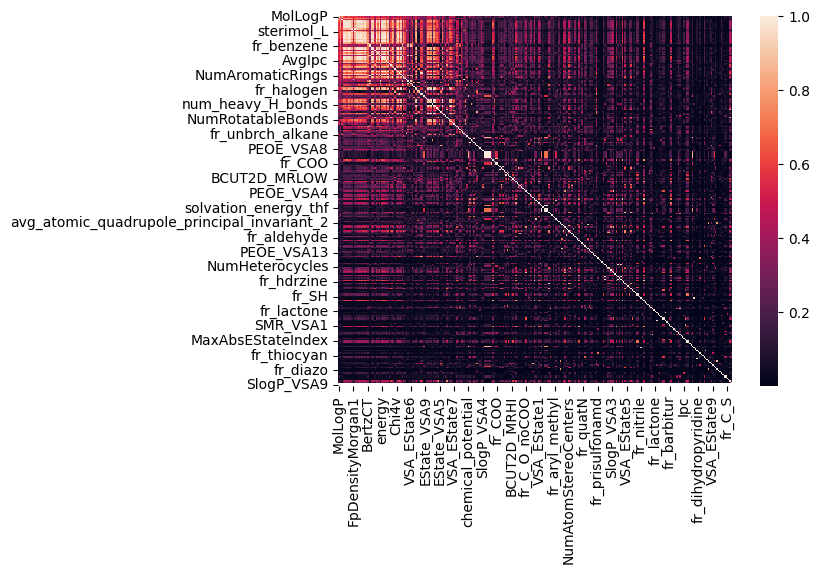

In [9]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)

sorted_features = corr_target.index
corr_sorted = X[sorted_features].corr()

sns.heatmap(corr_sorted.abs())
plt.show()

In [8]:
np.var(y)

np.float64(5.32633083355637)